# Teste para a média populacional com variância conhecida

**Enunciado:**

Uma variável aleatória $X$ tem distribuição normal e desvio padrão igual a 12. Estamos testando se a média é igual ou diferente a 20 e coletamos uma amostra de 100 valores dessa variável, obtendo uma média amostral de 17,4.

a. Formule as hipóteses.

b. Obtenha a região crítica e dê a conclusão do teste para $\alpha = 1\%$.

## a) Formulação das hipóteses

Como o enunciado pede um teste de **igualdade ou diferença**, trata-se de um teste **bilateral**:

$$H_0: \mu = 20$$
$$H_1: \mu \neq 20$$

## b) Região crítica e conclusão

Como $\sigma$ é conhecido, a estatística de teste segue distribuição Normal padrão:

$$Z = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}}$$

Vamos calcular tudo passo a passo em Python.

In [1]:
import numpy as np
from scipy import stats

# Dados do problema
sigma = 12       # desvio padrão populacional
n = 100           # tamanho da amostra
x_bar = 17.4      # média amostral
mu0 = 20          # média hipotética (H0)
alpha = 0.01      # nível de significância

# Erro padrão da média
erro_padrao = sigma / np.sqrt(n)
print(f"Erro padrão (sigma/raiz(n)) = {erro_padrao}")

# Estatística de teste Z
Z_calc = (x_bar - mu0) / erro_padrao
print(f"Z calculado = {Z_calc:.4f}")

Erro padrão (sigma/raiz(n)) = 1.2
Z calculado = -2.1667


In [2]:
# Valor crítico para teste bilateral (alpha/2 em cada cauda)
Z_critico = stats.norm.ppf(1 - alpha/2)
print(f"Z crítico (Z_alpha/2) = {Z_critico:.4f}")

print(f"\nRegião crítica: Z < -{Z_critico:.3f}  ou  Z > {Z_critico:.3f}")

Z crítico (Z_alpha/2) = 2.5758

Região crítica: Z < -2.576  ou  Z > 2.576


In [3]:
# p-valor (para teste bilateral)
p_valor = 2 * (1 - stats.norm.cdf(abs(Z_calc)))
print(f"p-valor = {p_valor:.4f}")

# Decisão
if abs(Z_calc) > Z_critico:
    decisao = "Rejeita-se H0"
else:
    decisao = "Não se rejeita H0"

print(f"\n|Z calculado| = {abs(Z_calc):.4f}")
print(f"Z crítico     = {Z_critico:.4f}")
print(f"\nDecisão: {decisao}")

p-valor = 0.0303

|Z calculado| = 2.1667
Z crítico     = 2.5758

Decisão: Não se rejeita H0


## Conclusão

Como $|Z_{calc}| \approx 2,17$ é **menor** que $Z_{crítico} \approx 2,575$, o valor calculado **não** cai na região crítica.

**Não rejeitamos $H_0$.** Ao nível de significância de 1%, não há evidência estatística suficiente para afirmar que a média populacional é diferente de 20 — os dados amostrais são compatíveis com $\mu = 20$.

## Visualização da região crítica

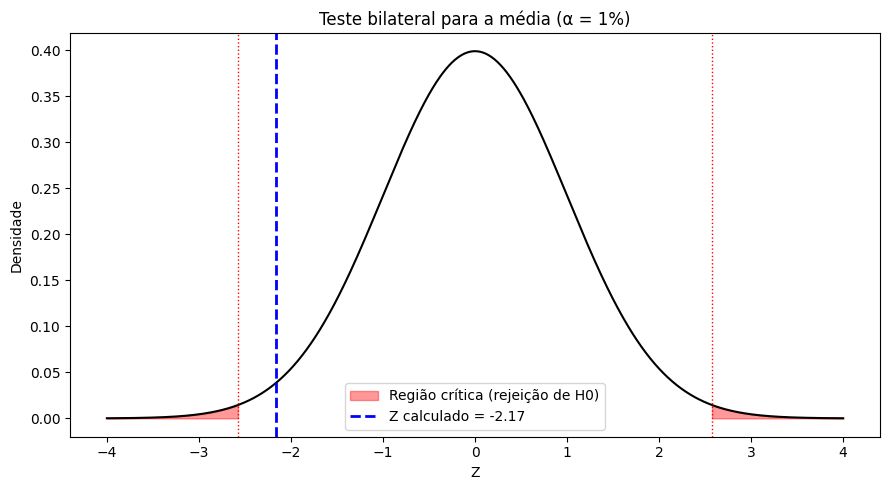

In [4]:
import matplotlib.pyplot as plt

x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, y, color='black', linewidth=1.5)

# Regiões de rejeição (caudas)
x_left = np.linspace(-4, -Z_critico, 100)
x_right = np.linspace(Z_critico, 4, 100)
ax.fill_between(x_left, stats.norm.pdf(x_left), color='red', alpha=0.4, label='Região crítica (rejeição de H0)')
ax.fill_between(x_right, stats.norm.pdf(x_right), color='red', alpha=0.4)

# Linha do Z calculado
ax.axvline(Z_calc, color='blue', linestyle='--', linewidth=2, label=f'Z calculado = {Z_calc:.2f}')

# Linhas dos valores críticos
ax.axvline(Z_critico, color='red', linestyle=':', linewidth=1)
ax.axvline(-Z_critico, color='red', linestyle=':', linewidth=1)

ax.set_title('Teste bilateral para a média (α = 1%)')
ax.set_xlabel('Z')
ax.set_ylabel('Densidade')
ax.legend()
plt.tight_layout()
plt.savefig('teste_hipotese.png', dpi=120)
plt.show()